# Neural Estate's Woningprijs Voorspeller

## 0 Teaminformatie

- **Team naam**: Groep 5
- **Namen**: Imran Funna, Rinesh Nanda
- **Kaggle Imran**: imranfunna
- **Kaggle Rinesh**: 

## 1 Inleiding


**Neural Estate** is een vastgoedtechnologiebedrijf wat slimme tools ontwikkelt voor makelaars, investeerders en huizenkopers waardoor zij een schatting kunnen krijgen op basis van visuele en numerieke data. Hun doel is dan ook om de woningmarkt te revolutioneren met AI.

Het belangrijkste product van Neural Estate is een AI powered ratingsystem dat de verkoopprijzen van huizen kan voorspellen. Om dit systeem te kunnen verbeteren heeft Neural Estate een grote woningsdataset verzameld uit 2016. De prijzen zijn niet meer actueel maar vormen nog steeds een realistische benchmark voor het bouwen van ml-modellen. 

Aan ons, een team juniore data scientists, wordt gevraagd om te helpen door een **neuraal netwerkmodel** te ontwerpen en te trainen dat de **verkoopprijs** zo nauwkeurig mogelijk voorspelt.

## 2 Dataset

Voor het bouwen van het neurale netwerkmodel hebben we data gekregen. Dat zijn twee soorten data:

1. Image Data
    - Slaapkamer
    - Badkamer
    - Keuken
    - Vooraanzicht

Deze vier afbeeldingen zijn samengevoegd tot één enkele afbeelding per huis. Wij zullen dit gebruiken als input voor een computer vision model.

2. Tabulair Data:
    - Oppervlakte
    - Aantal kamers
    - Lat- en Longitude
    - Prijs

## 3 EDA


In [1]:
# Importeren pandas voor EDA
import pandas as pd

df = pd.read_csv('train.csv')
display(df.head())

,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
0,1,4,4.0,4053,33.6968,-111.8892,869500
1,2,4,3.0,3343,34.8280,-119.0349,865200
2,3,3,4.0,3923,33.7669,-111.9182,889000
3,4,5,5.0,4022,33.7752,-111.7791,910000
4,5,3,4.0,4116,33.7669,-111.9182,971226


### 3.1 Afbeeldingen inlezen en voorbeelden tonen

We laden de trainingsmetadata en tonen enkele voorbeeldafbeeldingen uit de map `Train`.

Aantal rijen in metadata: 500
Aantal kolommen: 7


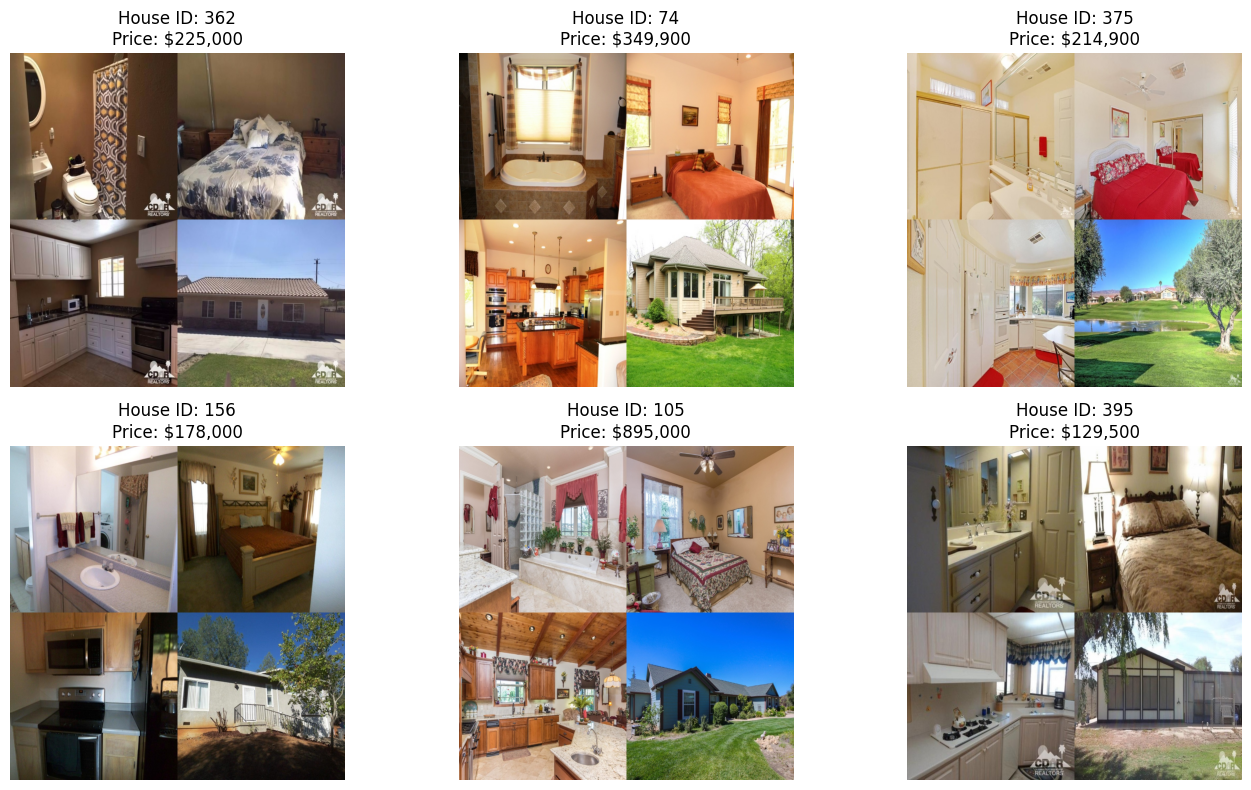

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Folder naam definieren
images_dir = Path('Train')

# Size en shape
print(f'Aantal rijen in metadata: {len(df)}')
print(f'Aantal kolommen: {df.shape[1]}')

# Enkele afbeeldingen dus we nemen 6 met fixed random state
sample_df = df.sample(6, random_state=42)

# Subplots maken
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# ID en prijs geven voor elke subplot
for ax, (_, row) in zip(axes, sample_df.iterrows()):

    # ID naar int en dan zoeken naar ID foto in Train folder
    house_id = int(row['House ID'])
    image_path = images_dir / f'{house_id}.jpg'

    # Foto inladen en laten zien met relevante info
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.set_title(f"House ID: {house_id}\nPrice: ${row['Price']:,.0f}")

    ax.axis('off')

for ax in axes[len(sample_df):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Hier staan een voorbeeld van enkele huizen zoals ze voorkomen in de dataset. ID en prijs is erbij gezet per huis.

### 3.2 Metadata analyseren en relaties met targetvariabele onderzoeken

We onderzoeken de relatie tussen `Price` (target) en de andere variabelen via samenvattingen en visualisaties.


Ontbrekende waarden per kolom:


,missing_values
House ID,0
Bedrooms,0
Bathrooms,0
Area,0
Latitude,0
Longitude,0
Price,0



Beschrijvende statistiek:


,House ID,Bedrooms,Bathrooms,Area,Latitude,Longitude,Price
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,5.000000e+02
mean,250.500000,3.350000,2.669500,2369.64600,35.128844,-116.469049,5.980218e+05
std,144.481833,1.172283,1.017578,1208.18261,2.386173,6.554434,5.240649e+05
min,1.000000,1.000000,1.000000,701.00000,32.631500,-122.368300,2.200000e+04
25%,125.750000,2.000000,2.000000,1440.00000,33.808200,-119.802500,2.350000e+05
50%,250.500000,3.000000,2.500000,2097.50000,33.920800,-117.609600,5.300000e+05
75%,375.250000,4.000000,3.000000,3104.50000,35.640600,-116.371300,7.490000e+05
max,500.000000,10.000000,7.000000,9583.00000,47.791800,-87.885900,5.858000e+06


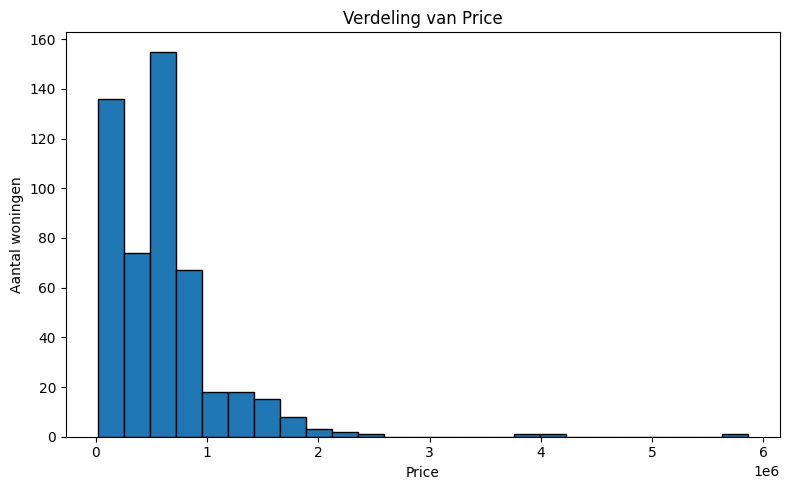

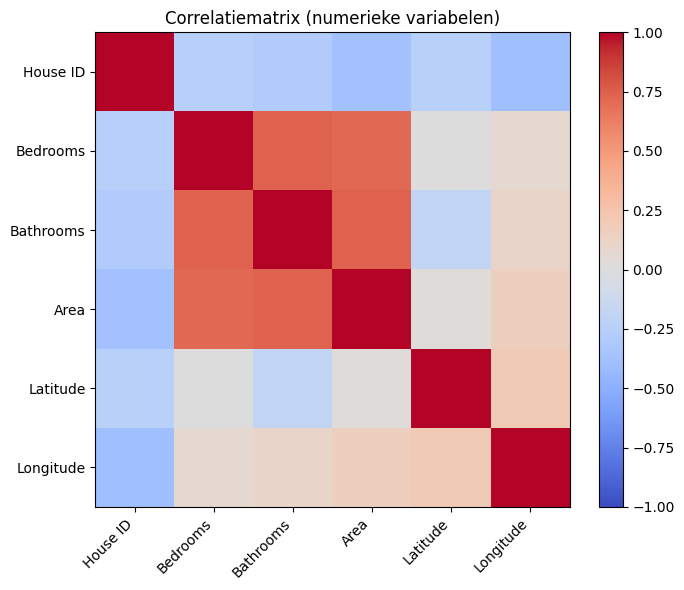

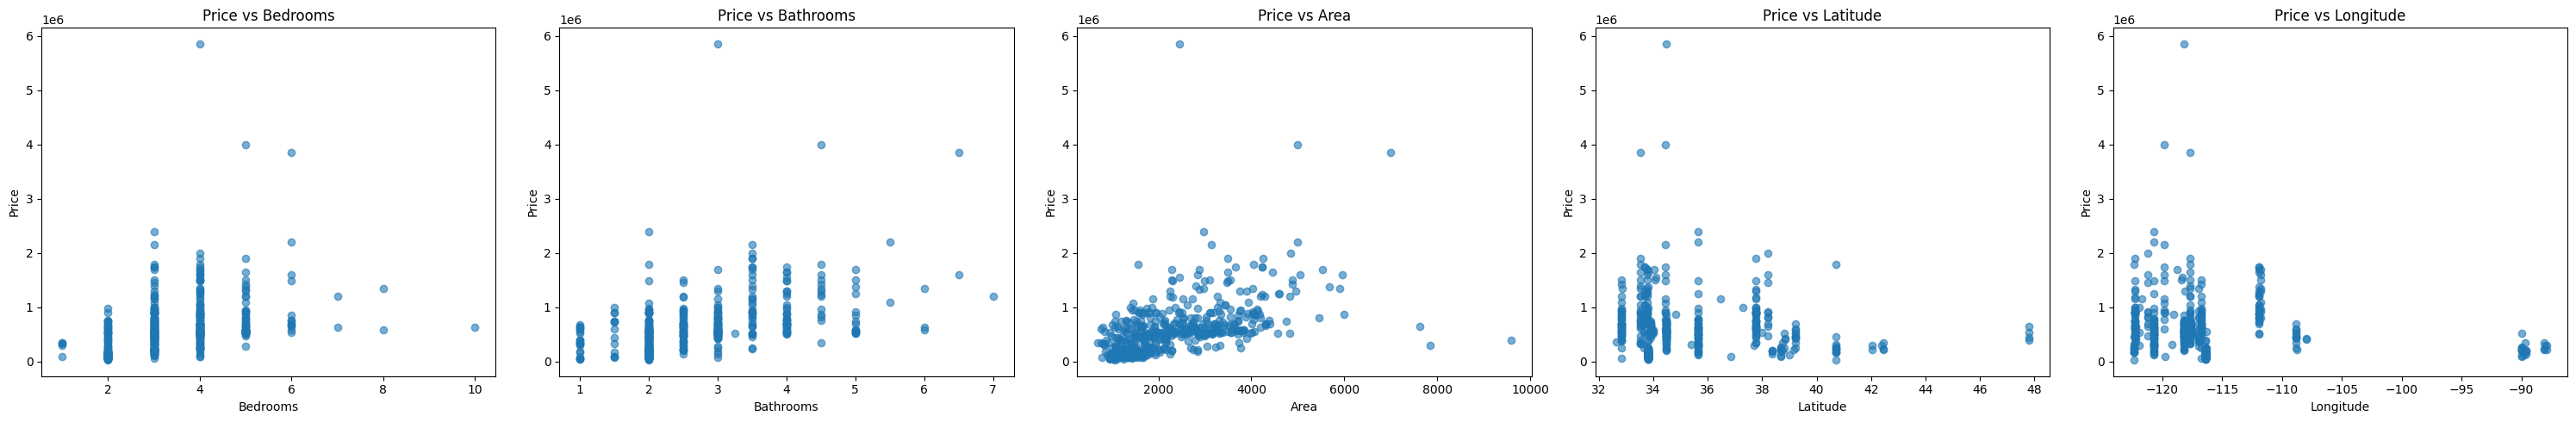

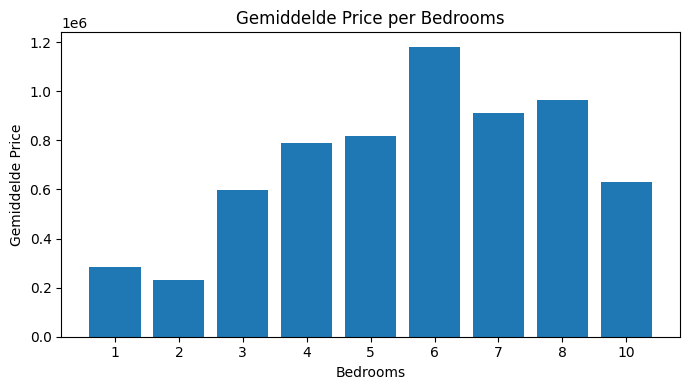

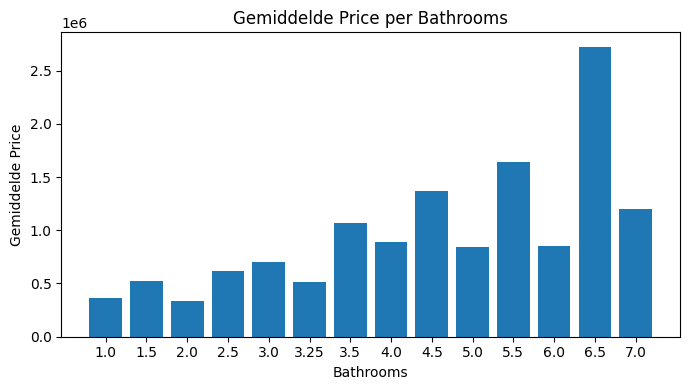

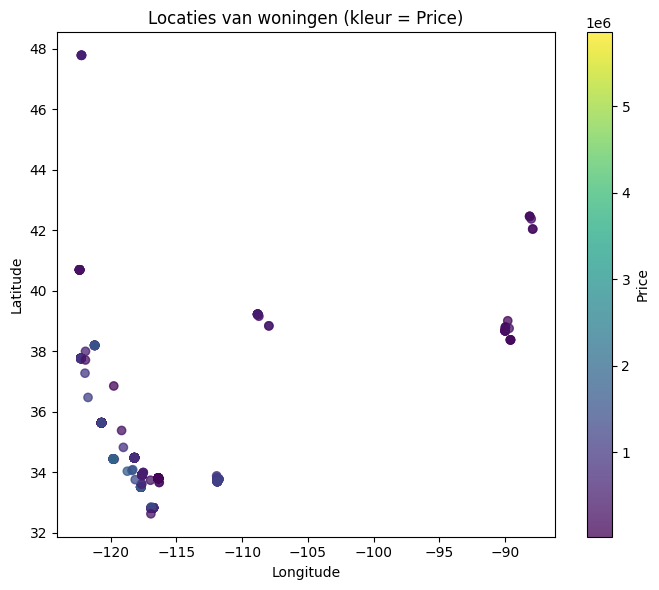

In [3]:
# We maken een lijst van de features (dus geen Price)
feature_cols = [col for col in df.columns if col != 'Price']

# We kijken of er ontbrekende waardes zijn en hoeveel
print('\nOntbrekende waarden per kolom:')
display(df.isna().sum().to_frame('missing_values'))

# Beschrijvende statistieken
print('\nBeschrijvende statistiek:')
display(df.describe(include='all'))

# We kijken naar de verdeling van de prijs
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Price'], bins=25, edgecolor='black')
ax.set_title('Verdeling van Price')
ax.set_xlabel('Price')
ax.set_ylabel('Aantal woningen')
plt.tight_layout()
plt.show()

# We kijken naar correlaties tussen de features
corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlatiematrix (numerieke variabelen)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

#Relatie Price vs elke feature (excl. House ID)
plot_features = [c for c in feature_cols if c not in ['Price', 'House ID']]

n = len(plot_features)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, plot_features):
    ax.scatter(df[col], df['Price'], alpha=0.6)
    ax.set_title(f'Price vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

#Gemiddelde prijs per aantal slaapkamers/badkamers
for group_col in ['Bedrooms', 'Bathrooms']:
    if group_col in df.columns:
        grouped = df.groupby(group_col)['Price'].mean().sort_index()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(grouped.index.astype(str), grouped.values)
        ax.set_title(f'Gemiddelde Price per {group_col}')
        ax.set_xlabel(group_col)
        ax.set_ylabel('Gemiddelde Price')
        plt.tight_layout()
        plt.show()

# Locatieplot (Latitude/Longitude) gekleurd op Price
if {'Latitude', 'Longitude', 'Price'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(df['Longitude'], df['Latitude'], c=df['Price'], cmap='viridis', alpha=0.75)
    ax.set_title('Locaties van woningen (kleur = Price)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Price')
    plt.tight_layout()
    plt.show()

### 3.3 Bevindingen

Na het uitvoeren van de EDA zijn we tot bepaalde conclusies gekomen.

1. Huizen kunnen zo goedkoop zijn als `$22.000` en oplopen tot `$5.858.000` zoals we hebben gezien in de beschrijvende statistieken.
2. Over het algemeen zijn de prijzen van de huizen aan de lagere kant van het spectrum, zoals we hebben gezien in de rechtsscheve verdelingen van de prijzen. Dit betekent dat de echt dure huizen (Bijvoorbeeld die van $5.858.000) duidelijk outliers zijn en de prijzen over het algemeen dichter op elkaar zitten en steeds minder voorkomt hoe hoger de prijs stijgt.
3. Zoals te zien in de correlatiematrix zien we dat `Area`, `Bedrooms` en `Bathrooms` een sterke **positieve** correlatie hebben met elkaar.
4. Als we kijken naar de kleinere subplots en dan inzoomen op `Area vs. Price` zien we dat over het algemeen hoe lager de area is, hoe lager de prijs is, met enkele uitschieters.
5. Als laatst zien we in de location plot dat huizen met een lagere lat- en longitude een wat hogere prijs hebben dan de locaties die een hogere lat- of longitude hebben.

## 4 Fully connected neuraal netwerk

### 4.1 Keuzes en motivatie

Voor deze deelopdracht gebruiken we alleen de **tabulaire variabelen** (`Area`, `Bedrooms`, `Bathrooms`, `Latitude`, `Longitude`) en voorspellen we `Price` met een dense neuraal netwerk.

- **Aantal lagen / neuronen**: we kiezen een compact MLP met 3 hidden layers (`128 -> 64 -> 32`). Dit geeft genoeg capaciteit voor niet-lineaire relaties zonder het model onnodig groot te maken.
- **Activeringsfunctie**: `ReLU` in hidden layers, omdat deze stabiel traint en effectief is voor regressieproblemen met geschaalde features.
- **Outputlaag**: 1 neuron met lineaire activatie, omdat we een continue waarde (prijs) voorspellen.
- **Lossfunctie**: we kiezen **MSE** (`mean_squared_error`) als primaire loss, omdat grote fouten bij prijsvoorspelling extra moeten doorwegen. Daarnaast rapporteren we `MAE` en `RMSE` als interpreteerbare metrics.
- **Optimizer**: **Adam** (`learning_rate=1e-3`), een optimizer die per parameter een adaptieve learning rate gebruikt via exponentieel voortschrijdende gemiddelden van gradiënten (eerste en tweede moment), wat vaak snelle en stabiele convergentie geeft.
- **Epochs**: maximaal 150 epochs met `EarlyStopping`; zo krijgt het model voldoende leertijd, maar stopt het automatisch zodra de validatiefout niet meer verbetert.

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import plot_model

# Reproduceerbaarheid
tf.random.set_seed(42)
np.random.seed(42)

# Zorg dat df beschikbaar is
if 'df' not in globals():
    import pandas as pd
    df = pd.read_csv('train.csv')

# Alleen tabulaire features gebruiken
X = df.drop(columns=['Price', 'House ID'], errors='ignore').copy()
y = df['Price'].astype('float32').copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling voor stabielere NN training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Door scheve prijsverdeling trainen we op log-prijs
y_train_log = np.log1p(y_train.values)
y_val_log = np.log1p(y_val.values)

print(f'Train shape: {X_train_scaled.shape}, Validatie shape: {X_val_scaled.shape}')
print('Features gebruikt:', list(X.columns))

Train shape: (400, 5), Validatie shape: (100, 5)
Features gebruikt: ['Bedrooms', 'Bathrooms', 'Area', 'Latitude', 'Longitude']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Automatische Keras-plot niet beschikbaar; fallback naar Matplotlib-schema.


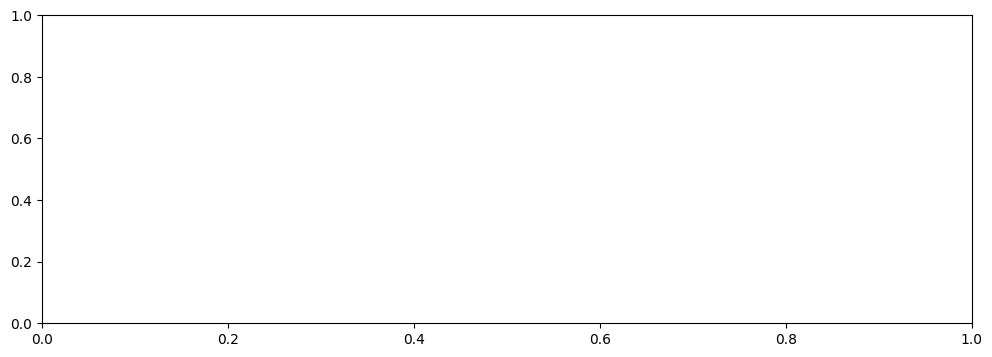

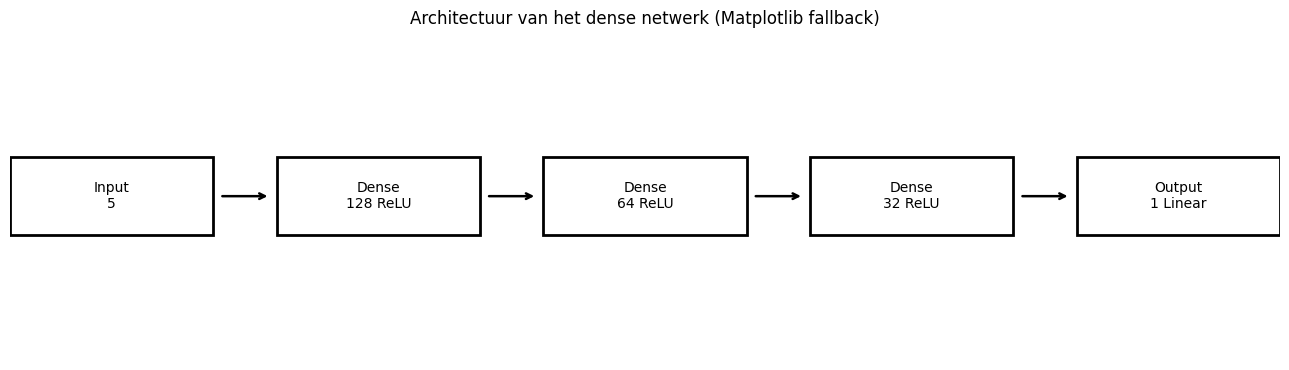

In [10]:
# Dense (fully-connected) regressiemodel
model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],), name='input_tabular'),
    layers.Dense(128, activation='relu', name='dense_128'),
    layers.Dense(64, activation='relu', name='dense_64'),
    layers.Dense(32, activation='relu', name='dense_32'),
    layers.Dense(1, activation='linear', name='price_output')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

model.summary()

# Architectuurplot opslaan en tonen
plot_path = Path('dense_model_architecture.png')

try:
    plot_model(
        model,
        to_file=str(plot_path),
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        dpi=120
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(mpimg.imread(plot_path))
    ax.axis('off')
    ax.set_title('Architectuur van het dense netwerk (Keras plot_model)')
    plt.tight_layout()
    plt.show()
except Exception:
    print('Automatische Keras-plot niet beschikbaar; fallback naar Matplotlib-schema.')

    layer_labels = ['Input\n5', 'Dense\n128 ReLU', 'Dense\n64 ReLU', 'Dense\n32 ReLU', 'Output\n1 Linear']
    x_positions = np.linspace(0.08, 0.92, len(layer_labels))

    fig, ax = plt.subplots(figsize=(13, 3.8))

    for i, (x, label) in enumerate(zip(x_positions, layer_labels)):
        rect = plt.Rectangle((x - 0.08, 0.38), 0.16, 0.24, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(x, 0.5, label, ha='center', va='center', fontsize=10)

        if i < len(layer_labels) - 1:
            ax.annotate(
                '',
                xy=(x_positions[i + 1] - 0.085, 0.5),
                xytext=(x + 0.085, 0.5),
                arrowprops=dict(arrowstyle='->', lw=1.8)
            )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Architectuur van het dense netwerk (Matplotlib fallback)')
    plt.tight_layout()
    plt.show()

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 158.7141 - mae: 12.5634 - rmse: 12.5982 - val_loss: 137.9823 - val_mae: 11.7091 - val_rmse: 11.7466
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 125.2288 - mae: 11.1071 - rmse: 11.1906 - val_loss: 93.0451 - val_mae: 9.4778 - val_rmse: 9.6460
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 76.9393 - mae: 8.4425 - rmse: 8.7715 - val_loss: 40.6019 - val_mae: 5.7636 - val_rmse: 6.3720
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 32.6643 - mae: 4.9356 - rmse: 5.7153 - val_loss: 23.7185 - val_mae: 3.7359 - val_rmse: 4.8702
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.3013 - mae: 3.6239 - rmse: 4.6153 - val_loss: 17.9992 - val_mae: 3.3023 - val_rmse: 4.2426
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.7322 - mae: 3.1513 - rmse: 3.8383 - val_loss: 11.7779 - val_mae: 2.5847 - val_rmse: 3.4319
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.4415 - mae

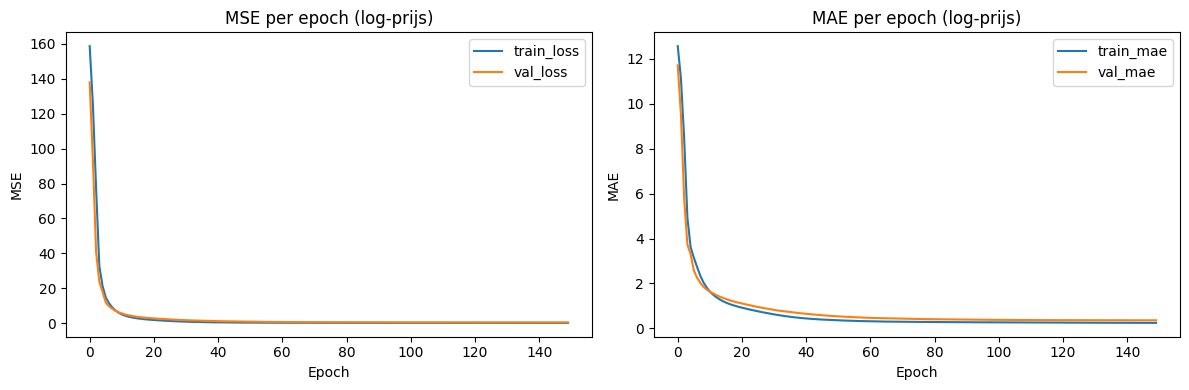

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Validatie MAE (prijs-schaal): $467,599.00
Validatie RMSE (prijs-schaal): $2,652,375.76
Totaal getrainde epochs: 150


In [11]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Leerproces visualiseren
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('MSE per epoch (log-prijs)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'], label='train_mae')
axes[1].plot(history.history['val_mae'], label='val_mae')
axes[1].set_title('MAE per epoch (log-prijs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluatie op originele prijsschaal
val_pred_log = model.predict(X_val_scaled).reshape(-1)
val_pred_price = np.expm1(val_pred_log)
val_true_price = np.expm1(y_val_log)

val_mae_price = mean_absolute_error(val_true_price, val_pred_price)
val_rmse_price = np.sqrt(mean_squared_error(val_true_price, val_pred_price))

print(f'Validatie MAE (prijs-schaal): ${val_mae_price:,.2f}')
print(f'Validatie RMSE (prijs-schaal): ${val_rmse_price:,.2f}')
print(f'Totaal getrainde epochs: {len(history.history["loss"])}')

bron: https://campus.datacamp.com/courses/introduction-to-deep-learning-in-python/fine-tuning-keras-models?ex=6